23070521054 - GAURI GULHANE

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 101ms/step - loss: 0.1701 - val_loss: 0.0729
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 47s 100ms/step - loss: 0.0708 - val_loss: 0.0685
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 98ms/step - loss: 0.0682 - val_loss: 0.0669


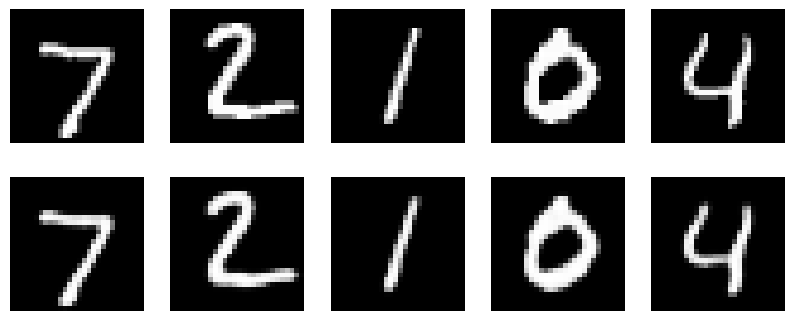

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# Load and preprocess MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

# Define convolutional autoencoder architecture
autoencoder = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, 3, activation="relu", padding="same", strides=2),
    layers.Conv2D(8, 3, activation="relu", padding="same", strides=2),
    layers.Conv2DTranspose(8, 3, activation="relu", padding="same", strides=2),
    layers.Conv2DTranspose(16, 3, activation="relu", padding="same", strides=2),
    layers.Conv2D(1, 3, activation="sigmoid", padding="same")
])

# Compile and train the model
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.fit(x_train, x_train, epochs=3, batch_size=128, validation_data=(x_test, x_test))

# Reconstruct and visualize the first 5 test images
reconstructed = autoencoder.predict(x_test[:5], verbose=0)
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.show()